In [ ]:
!pip install pymoo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.4 MB/s eta 0:00:00


In [ ]:
!pip install lifelines matplotlib

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=9c70ac89e7f4460f4721ac28ca049121a88dd1722ed5d8f16893f0002afdd980
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.base import clone
from collections import Counter
import shap
import math
from matplotlib import gridspec
from lifelines import CoxPHFitter
from matplotlib.patches import Rectangle
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

In [ ]:
df = pd.read_csv('sample_dataset.csv')
df

,ARHGEF10L,HIF3A,RNF17,RNF10,RNF11,RNF13,GTF2IP1,REM1,MTVR2,RTN4RL2,...,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS,TumorType
0,10.4567,7.2366,0.4503,12.2288,11.8107,9.9902,12.4704,5.2615,0.0000,5.2337,...,0.4503,5.3288,0.0000,9.0782,11.2214,6.7833,11.6090,2.4317,11.0901,Metastatic
1,8.3968,3.3893,0.0000,10.7424,10.4744,10.0415,12.4793,6.0612,0.3642,4.1423,...,3.6753,5.8901,0.0000,8.2274,11.9460,7.9559,10.9525,8.3120,9.4945,Metastatic
2,9.2700,1.4948,0.0000,12.1100,9.9002,10.2235,12.3415,2.8804,0.3818,5.3576,...,0.0000,3.1003,0.0000,10.4935,12.9077,6.7464,10.9070,3.9011,9.9979,Metastatic
3,9.3631,1.0980,0.3619,11.3904,9.8809,10.4280,12.3516,3.4938,0.0000,3.7291,...,0.0000,2.1446,0.0000,9.7932,12.4875,6.3319,11.0666,5.5778,10.3930,Primary
4,10.3084,4.3705,0.0000,11.6203,11.0004,11.4038,11.4320,5.6460,0.8733,6.2766,...,0.0000,6.1639,0.0000,9.1866,13.4410,9.6435,11.3559,9.0879,10.3138,Metastatic
5,9.1462,2.5251,1.5762,11.3769,10.7846,10.7288,12.7243,7.3912,0.0000,4.5358,...,3.0240,5.2121,2.7113,9.3838,13.2109,7.5912,11.5564,4.4337,10.1872,Metastatic
6,10.4445,0.4985,0.0000,11.9165,10.5825,10.2866,12.3080,4.6872,0.0000,5.4970,...,0.0000,5.3145,2.8461,9.5525,13.1218,5.9270,12.6922,6.2501,10.0843,Primary
7,9.4095,0.7433,0.0000,11.7101,9.8685,10.3824,11.5194,2.4278,0.0000,5.7066,...,0.0000,5.4638,0.0000,10.6387,13.9959,6.4913,12.0457,6.4136,10.0624,Metastatic
8,10.3927,1.2454,0.0000,11.5568,10.6654,10.3338,12.5589,2.0301,0.0000,3.5390,...,0.0000,3.1509,0.4251,10.1397,9.7507,5.6241,11.7218,3.2581,10.0921,Metastatic
9,10.3279,0.6003,0.0000,12.3950,9.9119,8.3829,11.7669,3.7424,0.6003,7.1112,...,0.0000,4.2525,0.0000,10.1480,12.8231,6.9216,11.7469,4.4008,9.7371,Primary


**Step-1: Preliminary Gene Screening**

In [ ]:
X = df.drop(columns=['TumorType'], errors='ignore')
y = (df['TumorType'] == 'Metastatic').astype(int)

# ============================================================
# Feature selection settings
# ============================================================

feature_numbers = [300, 400, 500, 600, 700, 800, 900, 1000]

selection_methods = {
    "ANOVA": f_classif,
    "Mutual_Information": mutual_info_classif
}


# ============================================================
# Classifiers
# ============================================================

classifiers = {
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boost": GradientBoostingClassifier(
        learning_rate=0.1,
        max_depth=5,
        n_estimators=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Logistic Regression": LogisticRegression(
        C=1,
        penalty="l1",
        solver="liblinear",
        max_iter=500
    ),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        min_samples_split=5,
        max_depth=None,
        random_state=42
    ),

    "SVC": SVC(
        C=0.1,
        class_weight=None,
        gamma="scale",
        kernel="linear",
        probability=True
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=11,
        eval_metric="logloss"
    )
}


# ============================================================
# Cross-validation setup
# ============================================================

n_splits = 5
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)


# ============================================================
# Run feature selection + classifier evaluation
# ============================================================

all_results = []
feature_set_summary = []

best_accuracy = -1
best_selection_method = None
best_k = None
best_classifier = None
best_selected_features = None

for selection_name, score_function in selection_methods.items():

    print(f"\n==============================")
    print(f"Feature Selection: {selection_name}")
    print(f"==============================")

    for k in feature_numbers:

        if k > X.shape[1]:
            print(f"Skipping k={k}, because X only has {X.shape[1]} features.")
            continue

        print(f"\n--- Evaluating top {k} features using {selection_name} ---")

        # Select top k features
        selector = SelectKBest(score_func=score_function, k=k)
        X_selected = selector.fit_transform(X, y)

        selected_feature_names = X.columns[
            selector.get_support(indices=True)
        ]

        X_selected_df = pd.DataFrame(
            X_selected,
            columns=selected_feature_names,
            index=X.index
        )

        # Evaluate each classifier
        for clf_name, clf in classifiers.items():

            fold_metrics = []

            for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected_df, y)):

                X_train = X_selected_df.iloc[train_idx]
                X_test = X_selected_df.iloc[test_idx]

                y_train = y.iloc[train_idx]
                y_test = y.iloc[test_idx]

                X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(
                    X_train,
                    y_train,
                    test_size=0.2,
                    random_state=42,
                    stratify=y_train
                )

                model = clone(clf)
                model.fit(X_train_fold, y_train_fold)

                y_pred = model.predict(X_test)

                acc = accuracy_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
                rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
                f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)

                fold_metrics.append({
                    "Selection_Method": selection_name,
                    "Number_of_Features": k,
                    "Classifier": clf_name,
                    "Fold": fold + 1,
                    "Accuracy": acc,
                    "Precision": prec,
                    "Recall": rec,
                    "F1-score": f1
                })

            accs = [m["Accuracy"] for m in fold_metrics]
            precs = [m["Precision"] for m in fold_metrics]
            recs = [m["Recall"] for m in fold_metrics]
            f1s = [m["F1-score"] for m in fold_metrics]

            avg_result = {
                "Selection_Method": selection_name,
                "Number_of_Features": k,
                "Classifier": clf_name,
                "Accuracy": np.mean(accs),
                "Accuracy_std": np.std(accs),
                "Precision": np.mean(precs),
                "Precision_std": np.std(precs),
                "Recall": np.mean(recs),
                "Recall_std": np.std(recs),
                "F1-score": np.mean(f1s),
                "F1-score_std": np.std(f1s)
            }

            all_results.append(avg_result)

            print(
                f"{selection_name} | Top {k} | {clf_name}: "
                f"Accuracy = {avg_result['Accuracy']:.3f} ± {avg_result['Accuracy_std']:.3f}, "
                f"Precision = {avg_result['Precision']:.3f} ± {avg_result['Precision_std']:.3f}, "
                f"Recall = {avg_result['Recall']:.3f} ± {avg_result['Recall_std']:.3f}, "
                f"F1 = {avg_result['F1-score']:.3f} ± {avg_result['F1-score_std']:.3f}"
            )

            # Track best result based on accuracy
            if avg_result["Accuracy"] > best_accuracy:
                best_accuracy = avg_result["Accuracy"]
                best_selection_method = selection_name
                best_k = k
                best_classifier = clf_name
                best_selected_features = selected_feature_names


# ============================================================
# Save all classifier results
# ============================================================

results_df = pd.DataFrame(all_results)

results_df.to_csv(
    "all_feature_selection_classifier_results.csv",
    index=False
)

print("\nSaved: all_feature_selection_classifier_results.csv")


# ============================================================
# Compare feature sets based on accuracy
# Average over all classifiers for each feature-selection setting
# ============================================================

feature_set_comparison = (
    results_df
    .groupby(["Selection_Method", "Number_of_Features"])
    .agg(
        Mean_Accuracy=("Accuracy", "mean"),
        Std_Accuracy=("Accuracy", "std"),
        Mean_Precision=("Precision", "mean"),
        Mean_Recall=("Recall", "mean"),
        Mean_F1=("F1-score", "mean")
    )
    .reset_index()
    .sort_values(by="Mean_Accuracy", ascending=False)
)

feature_set_comparison.to_csv(
    "feature_set_accuracy_comparison.csv",
    index=False
)

print("\nSaved: feature_set_accuracy_comparison.csv")

print("\nAccuracy comparison between all 16 feature sets:")
print(feature_set_comparison)


# ============================================================
# Best classifier-level result
# ============================================================

print("\n======================================")
print("Most optimal feature set based on accuracy")
print("======================================")
print(f"Selection method: {best_selection_method}")
print(f"Number of features: {best_k}")
print(f"Best classifier: {best_classifier}")
print(f"Best accuracy: {best_accuracy:.4f}")


# ============================================================
# Save dataframe with the most optimal feature set
# ============================================================

optimal_feature_df = pd.concat(
    [
        df[["index"]].reset_index(drop=True) if "index" in df.columns else pd.DataFrame(),
        X[best_selected_features].reset_index(drop=True),
        y.reset_index(drop=True).rename("TumorType")
    ],
    axis=1
)

optimal_filename = (
    f"SKCM_best_{best_selection_method}_top{best_k}_features.csv"
)

optimal_feature_df.to_csv(optimal_filename, index=False)

print(f"\nSaved optimal feature dataset: {optimal_filename}")


Feature Selection: ANOVA

--- Evaluating top 300 features using ANOVA ---


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   41   143   144   209   214   283   284   294   297   311   321   351
   365   439   565   567   710   715   732   783   819   839   878   982
   990  1046  1077  1100  1188  1234  1240  1255  1256  1257  1259  1308
  1338  1367  1369  1399  1425  1430  1459  1461  1505  1619  1628  1655
  1735  1743  1765  1766  1792  1891  1932  1993  1994  2003  2018  2031
  2032  2043  2044  2077  2135  2223  2224  2225  2231  2236  2252  2258
  2267  2269  2353  2409  2430  2476  2515  2635  2646  2652  2690  2691
  2693  2698  2699  2733  2750  2782  2794  2800  2889  2903  2922  2942
  2944  3039  3048  3049  3054  3076  3078  3079  3144  3155  3206  3251
  3273  3284  3288  3369  3370  3399  3425  3463  3472  3487  3536  3551
  3627  3629  3785  3825  3874  3895  3934  3952  3972  3994  4017  4026
  4036  4041  4050  4051  4052  4077  4115  4135  4205  4216  4470  4548
  4555

ANOVA | Top 300 | AdaBoost: Accuracy = 0.725 ± 0.094, Precision = 0.683 ± 0.080, Recall = 0.850 ± 0.122, F1 = 0.754 ± 0.084
ANOVA | Top 300 | Decision Tree: Accuracy = 0.775 ± 0.094, Precision = 0.803 ± 0.167, Recall = 0.800 ± 0.100, F1 = 0.786 ± 0.072
ANOVA | Top 300 | Extra Trees: Accuracy = 0.875 ± 0.079, Precision = 0.870 ± 0.108, Recall = 0.900 ± 0.122, F1 = 0.877 ± 0.080
ANOVA | Top 300 | Gradient Boost: Accuracy = 0.750 ± 0.079, Precision = 0.803 ± 0.167, Recall = 0.750 ± 0.158, F1 = 0.748 ± 0.075
ANOVA | Top 300 | KNN: Accuracy = 0.950 ± 0.061, Precision = 1.000 ± 0.000, Recall = 0.900 ± 0.122, F1 = 0.943 ± 0.070
ANOVA | Top 300 | Logistic Regression: Accuracy = 0.825 ± 0.170, Precision = 0.813 ± 0.165, Recall = 0.850 ± 0.200, F1 = 0.825 ± 0.176
ANOVA | Top 300 | Naive Bayes: Accuracy = 0.850 ± 0.122, Precision = 0.960 ± 0.080, Recall = 0.750 ± 0.274, F1 = 0.801 ± 0.207
ANOVA | Top 300 | Random Forest: Accuracy = 0.925 ± 0.061, Precision = 0.880 ± 0.098, Recall = 1.000 ± 0.000,

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   41   143   144   209   214   283   284   294   297   311   321   351
   365   439   565   567   710   715   732   783   819   839   878   982
   990  1046  1077  1100  1188  1234  1240  1255  1256  1257  1259  1308
  1338  1367  1369  1399  1425  1430  1459  1461  1505  1619  1628  1655
  1735  1743  1765  1766  1792  1891  1932  1993  1994  2003  2018  2031
  2032  2043  2044  2077  2135  2223  2224  2225  2231  2236  2252  2258
  2267  2269  2353  2409  2430  2476  2515  2635  2646  2652  2690  2691
  2693  2698  2699  2733  2750  2782  2794  2800  2889  2903  2922  2942
  2944  3039  3048  3049  3054  3076  3078  3079  3144  3155  3206  3251
  3273  3284  3288  3369  3370  3399  3425  3463  3472  3487  3536  3551
  3627  3629  3785  3825  3874  3895  3934  3952  3972  3994  4017  4026
  4036  4041  4050  4051  4052  4077  4115  4135  4205  4216  4470  4548
  4555

ANOVA | Top 400 | AdaBoost: Accuracy = 0.725 ± 0.094, Precision = 0.713 ± 0.071, Recall = 0.750 ± 0.158, F1 = 0.725 ± 0.105
ANOVA | Top 400 | Decision Tree: Accuracy = 0.775 ± 0.050, Precision = 0.833 ± 0.139, Recall = 0.750 ± 0.158, F1 = 0.765 ± 0.063
ANOVA | Top 400 | Extra Trees: Accuracy = 0.900 ± 0.050, Precision = 0.880 ± 0.098, Recall = 0.950 ± 0.100, F1 = 0.905 ± 0.049
ANOVA | Top 400 | Gradient Boost: Accuracy = 0.775 ± 0.050, Precision = 0.817 ± 0.153, Recall = 0.800 ± 0.187, F1 = 0.775 ± 0.064
ANOVA | Top 400 | KNN: Accuracy = 0.900 ± 0.122, Precision = 0.950 ± 0.100, Recall = 0.850 ± 0.200, F1 = 0.883 ± 0.145
ANOVA | Top 400 | Logistic Regression: Accuracy = 0.850 ± 0.146, Precision = 0.880 ± 0.160, Recall = 0.850 ± 0.200, F1 = 0.844 ± 0.151
ANOVA | Top 400 | Naive Bayes: Accuracy = 0.800 ± 0.170, Precision = 0.750 ± 0.387, Recall = 0.650 ± 0.339, F1 = 0.693 ± 0.355
ANOVA | Top 400 | Random Forest: Accuracy = 0.900 ± 0.050, Precision = 0.840 ± 0.080, Recall = 1.000 ± 0.000,

...

ANOVA | Top 800 | AdaBoost: Accuracy = 0.725 ± 0.094, Precision = 0.700 ± 0.084, Recall = 0.800 ± 0.100, F1 = 0.744 ± 0.081
ANOVA | Top 800 | Decision Tree: Accuracy = 0.750 ± 0.112, Precision = 0.763 ± 0.137, Recall = 0.750 ± 0.158, F1 = 0.747 ± 0.118
ANOVA | Top 800 | Extra Trees: Accuracy = 0.825 ± 0.127, Precision = 0.843 ± 0.135, Recall = 0.800 ± 0.187, F1 = 0.813 ± 0.145
ANOVA | Top 800 | Gradient Boost: Accuracy = 0.725 ± 0.146, Precision = 0.713 ± 0.173, Recall = 0.850 ± 0.122, F1 = 0.763 ± 0.111
ANOVA | Top 800 | KNN: Accuracy = 0.900 ± 0.094, Precision = 0.910 ± 0.111, Recall = 0.900 ± 0.122, F1 = 0.899 ± 0.094
ANOVA | Top 800 | Logistic Regression: Accuracy = 0.850 ± 0.146, Precision = 0.843 ± 0.135, Recall = 0.850 ± 0.200, F1 = 0.842 ± 0.164
ANOVA | Top 800 | Naive Bayes: Accuracy = 0.825 ± 0.150, Precision = 1.000 ± 0.000, Recall = 0.650 ± 0.300, F1 = 0.747 ± 0.229
ANOVA | Top 800 | Random Forest: Accuracy = 0.850 ± 0.050, Precision = 0.830 ± 0.087, Recall = 0.900 ± 0.122,

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   41   143   144   209   214   283   284   294   297   311   321   351
   365   439   565   567   710   715   732   783   819   839   878   982
   990  1046  1077  1100  1188  1234  1240  1255  1256  1257  1259  1308
  1338  1367  1369  1399  1425  1430  1459  1461  1505  1619  1628  1655
  1735  1743  1765  1766  1792  1891  1932  1993  1994  2003  2018  2031
  2032  2043  2044  2077  2135  2223  2224  2225  2231  2236  2252  2258
  2267  2269  2353  2409  2430  2476  2515  2635  2646  2652  2690  2691
  2693  2698  2699  2733  2750  2782  2794  2800  2889  2903  2922  2942
  2944  3039  3048  3049  3054  3076  3078  3079  3144  3155  3206  3251
  3273  3284  3288  3369  3370  3399  3425  3463  3472  3487  3536  3551
  3627  3629  3785  3825  3874  3895  3934  3952  3972  3994  4017  4026
  4036  4041  4050  4051  4052  4077  4115  4135  4205  4216  4470  4548
  4555

ANOVA | Top 900 | AdaBoost: Accuracy = 0.725 ± 0.094, Precision = 0.700 ± 0.084, Recall = 0.800 ± 0.100, F1 = 0.744 ± 0.081
ANOVA | Top 900 | Decision Tree: Accuracy = 0.675 ± 0.218, Precision = 0.667 ± 0.242, Recall = 0.750 ± 0.274, F1 = 0.691 ± 0.223
ANOVA | Top 900 | Extra Trees: Accuracy = 0.900 ± 0.094, Precision = 0.950 ± 0.100, Recall = 0.850 ± 0.122, F1 = 0.893 ± 0.096
ANOVA | Top 900 | Gradient Boost: Accuracy = 0.725 ± 0.146, Precision = 0.713 ± 0.173, Recall = 0.850 ± 0.122, F1 = 0.763 ± 0.111
ANOVA | Top 900 | KNN: Accuracy = 0.900 ± 0.094, Precision = 0.910 ± 0.111, Recall = 0.900 ± 0.122, F1 = 0.899 ± 0.094
ANOVA | Top 900 | Logistic Regression: Accuracy = 0.850 ± 0.146, Precision = 0.843 ± 0.135, Recall = 0.850 ± 0.200, F1 = 0.842 ± 0.164
ANOVA | Top 900 | Naive Bayes: Accuracy = 0.800 ± 0.187, Precision = 0.800 ± 0.400, Recall = 0.600 ± 0.374, F1 = 0.667 ± 0.365
ANOVA | Top 900 | Random Forest: Accuracy = 0.925 ± 0.061, Precision = 0.880 ± 0.098, Recall = 1.000 ± 0.000,

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   41   143   144   209   214   283   284   294   297   311   321   351
   365   439   565   567   710   715   732   783   819   839   878   982
   990  1046  1077  1100  1188  1234  1240  1255  1256  1257  1259  1308
  1338  1367  1369  1399  1425  1430  1459  1461  1505  1619  1628  1655
  1735  1743  1765  1766  1792  1891  1932  1993  1994  2003  2018  2031
  2032  2043  2044  2077  2135  2223  2224  2225  2231  2236  2252  2258
  2267  2269  2353  2409  2430  2476  2515  2635  2646  2652  2690  2691
  2693  2698  2699  2733  2750  2782  2794  2800  2889  2903  2922  2942
  2944  3039  3048  3049  3054  3076  3078  3079  3144  3155  3206  3251
  3273  3284  3288  3369  3370  3399  3425  3463  3472  3487  3536  3551
  3627  3629  3785  3825  3874  3895  3934  3952  3972  3994  4017  4026
  4036  4041  4050  4051  4052  4077  4115  4135  4205  4216  4470  4548
  4555

ANOVA | Top 1000 | AdaBoost: Accuracy = 0.700 ± 0.061, Precision = 0.673 ± 0.067, Recall = 0.800 ± 0.100, F1 = 0.727 ± 0.052
ANOVA | Top 1000 | Decision Tree: Accuracy = 0.775 ± 0.050, Precision = 0.867 ± 0.163, Recall = 0.750 ± 0.224, F1 = 0.758 ± 0.078
ANOVA | Top 1000 | Extra Trees: Accuracy = 0.825 ± 0.127, Precision = 0.843 ± 0.135, Recall = 0.800 ± 0.187, F1 = 0.813 ± 0.145
ANOVA | Top 1000 | Gradient Boost: Accuracy = 0.775 ± 0.094, Precision = 0.763 ± 0.137, Recall = 0.850 ± 0.122, F1 = 0.793 ± 0.079
ANOVA | Top 1000 | KNN: Accuracy = 0.875 ± 0.079, Precision = 0.870 ± 0.108, Recall = 0.900 ± 0.122, F1 = 0.877 ± 0.080
ANOVA | Top 1000 | Logistic Regression: Accuracy = 0.850 ± 0.146, Precision = 0.843 ± 0.135, Recall = 0.850 ± 0.200, F1 = 0.842 ± 0.164
ANOVA | Top 1000 | Naive Bayes: Accuracy = 0.800 ± 0.187, Precision = 0.800 ± 0.400, Recall = 0.600 ± 0.374, F1 = 0.667 ± 0.365
ANOVA | Top 1000 | Random Forest: Accuracy = 0.850 ± 0.094, Precision = 0.820 ± 0.093, Recall = 0.900 

**Step-2: Pareto Optimal Gene Refinement**


==== Running NSGA-II feature selection with CV for AdaBoost ====
Model: AdaBoost, Fold 1/5
Model: AdaBoost, Fold 2/5
Model: AdaBoost, Fold 3/5
Model: AdaBoost, Fold 4/5
Model: AdaBoost, Fold 5/5

==== Running NSGA-II feature selection with CV for Decision Tree ====
Model: Decision Tree, Fold 1/5
Model: Decision Tree, Fold 2/5
Model: Decision Tree, Fold 3/5
Model: Decision Tree, Fold 4/5
Model: Decision Tree, Fold 5/5

==== Running NSGA-II feature selection with CV for Extra Trees ====
Model: Extra Trees, Fold 1/5
Model: Extra Trees, Fold 2/5
Model: Extra Trees, Fold 3/5
Model: Extra Trees, Fold 4/5
Model: Extra Trees, Fold 5/5

==== Running NSGA-II feature selection with CV for Gradient Boost ====
Model: Gradient Boost, Fold 1/5
Model: Gradient Boost, Fold 2/5
Model: Gradient Boost, Fold 3/5
Model: Gradient Boost, Fold 4/5
Model: Gradient Boost, Fold 5/5

==== Running NSGA-II feature selection with CV for KNN ====
Model: KNN, Fold 1/5
Model: KNN, Fold 2/5
Model: KNN, Fold 3/5
Model: K

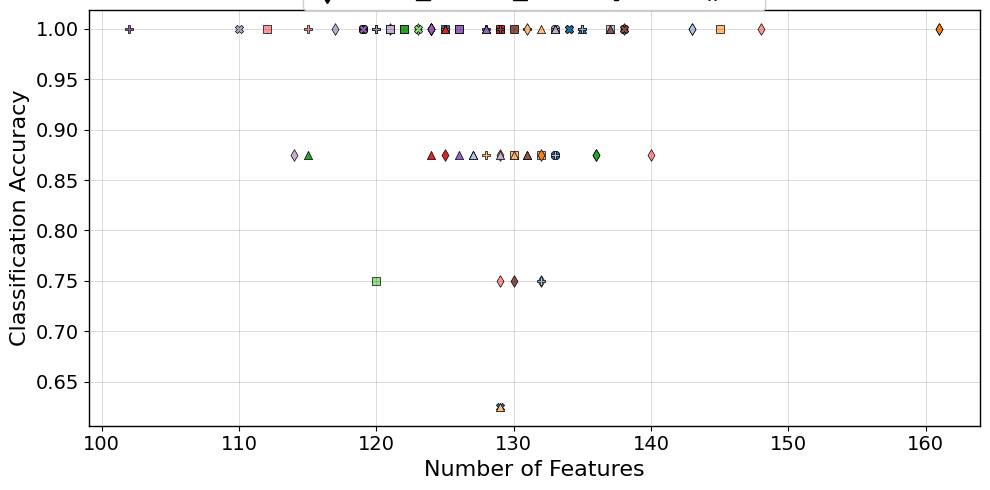

Saved all Pareto front results to CV_ParetoFront_SelectedModels.csv


In [ ]:
df1 = pd.read_csv('SKCM_best_ANOVA_top400_features.csv') #Update the filename
X = df1.drop(columns=['TumorType'], errors='ignore')
y = df1['TumorType']

feature_names = X.columns.tolist()

ALL_MODELS = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=None, random_state=42),
    "SVC": SVC(C=0.1, class_weight=None, gamma='scale', kernel='linear', probability=True),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=11, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', alpha=1e-4, learning_rate_init=1e-3, max_iter=200, random_state=42),
}

ABBR = {
    "AdaBoost": "AB",
    "Decision Tree": "DT",
    "Extra Trees": "ET",
    "Gradient Boost": "GB",
    "KNN": "KNN",
    "Logistic Regression": "LR",
    "Naive Bayes": "NB",
    "Random Forest": "RF",
    "SVC": "SVC",
    "XGBoost": "XGB",
    "MLP": "MLP",
}

# 2. Choose which models to run
SELECTED_MODEL_NAMES = ["AdaBoost", "Decision Tree", "Extra Trees", "Gradient Boost", "KNN", "Logistic Regression", "Naive Bayes", "Random Forest", "SVC", "MLP", "XGBoost"]

# Build selected model dict (and validate names)
missing = [m for m in SELECTED_MODEL_NAMES if m not in ALL_MODELS]
if missing:
    raise ValueError(f"Unknown model names in SELECTED_MODEL_NAMES: {missing}\n"
                     f"Available: {list(ALL_MODELS.keys())}")

models = {name: ALL_MODELS[name] for name in SELECTED_MODEL_NAMES}
abbr = {name: ABBR[name] for name in SELECTED_MODEL_NAMES}

cmap = plt.get_cmap("tab20")
colors = [cmap(i % 20) for i in range(len(models))]

markers = ['d', 's', '^', 'P', 'X']  # for folds

# 3. NSGA-II feature selection with chosen models
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

pareto_full_results = []

fig, ax = plt.subplots(figsize=(10, 5))

for model_idx, (model_name, model_template) in enumerate(models.items()):
    print(f"\n==== Running NSGA-II feature selection with CV for {model_name} ====")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        print(f"Model: {model_name}, Fold {fold}/{n_splits}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        class FeatureSelectionProblem(ElementwiseProblem):
            def __init__(self):
                super().__init__(n_var=len(feature_names), n_obj=2, n_constr=0, xl=0, xu=1)

            def _evaluate(self, x, out, *args, **kwargs):
                indices = np.where(x >= 0.5)[0]
                if len(indices) == 0:
                    out["F"] = [1, 0]  # worst: 1 feature and 0 accuracy
                    return

                sel_feats = [feature_names[i] for i in indices]
                X_train_sel = X_train[sel_feats]
                X_test_sel = X_test[sel_feats]

                try:
                    clf = clone(model_template)  # safe fresh copy each evaluation
                    clf.fit(X_train_sel, y_train)
                    preds = clf.predict(X_test_sel)
                    acc = accuracy_score(y_test, preds)
                except Exception:
                    acc = 0.0

                # minimize (#features), minimize (-accuracy) == maximize accuracy
                out["F"] = [len(indices), -acc]

        problem = FeatureSelectionProblem()
        algorithm = NSGA2(pop_size=50, n_offsprings=10, eliminate_duplicates=True)
        res = minimize(problem, algorithm, ('n_gen', 50), verbose=False)

        pareto = res.F
        num_features = pareto[:, 0]
        accuracy = -pareto[:, 1]

        ax.scatter(
            num_features, accuracy,
            label=f"{abbr[model_name]}-F{fold}",
            color=colors[model_idx],
            marker=markers[(fold - 1) % len(markers)],
            s=35,
            alpha=1,
            edgecolor='black',
            linewidths=0.5
        )

        # Save results
        for i, (num_feats, acc_neg) in enumerate(pareto):
            x_ind = res.X[i]
            selected_indices = np.where(x_ind >= 0.5)[0]
            selected_names = [feature_names[j] for j in selected_indices]

            pareto_full_results.append({
                "Classifier": abbr[model_name],
                "Fold": f"F{fold}",
                "Accuracy": -acc_neg,
                "Number of Features": int(num_feats),
                "Feature Names": "|".join(selected_names)
            })

# 4. Plot styling and legends
ax.set_facecolor('white')
fig.patch.set_alpha(0.0)
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

ax.grid(True, color='black', linewidth=0.5, alpha=0.2)
ax.set_xlabel("Number of Features", fontsize=16)
ax.set_ylabel("Classification Accuracy", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# Legend for classifiers (colors)
handles_classifier = []
for i, name in enumerate(models.keys()):
    h = plt.Line2D(
        [0], [0],
        color=colors[i],
        marker='o',
        linestyle='',
        markersize=10,
        label=abbr[name]
    )
    handles_classifier.append(h)
ax.legend(handles=handles_classifier, fontsize=12, frameon=True,
          loc='lower right', title='Models')

# Legend for folds (markers)
handles_folds = []
fold_labels = [f"f{i}" for i in range(1, n_splits + 1)]
for fold in range(1, n_splits + 1):
    h = plt.Line2D(
        [0], [0],
        color='black',
        marker=markers[(fold - 1) % len(markers)],
        linestyle='',
        markersize=10,
        label=fold_labels[fold - 1]
    )
    handles_folds.append(h)
fold_legend = ax.legend(handles=handles_folds, fontsize=12, frameon=True,
                        loc='upper center', bbox_to_anchor=(0.5, 1.15),
                        ncol=n_splits, title='Folds')
ax.add_artist(fold_legend)

plt.tight_layout()
plt.savefig("CV_ParetoFront_SelectedModels.pdf", dpi=500, transparent=True)
plt.show()

pareto_full_results_df = pd.DataFrame(pareto_full_results)
pareto_full_results_df.to_csv("CV_ParetoFront_SelectedModels.csv", index=False)
print("Saved all Pareto front results to CV_ParetoFront_SelectedModels.csv")

In [ ]:
NSGA_RESULTS_CSV = "CV_ParetoFront_SelectedModels.csv"
DATA_CSV = "SKCM_best_ANOVA_top400_features.csv" #Update the filename

# Choose which feature-sets to consider (sources from NSGA file)
SOURCE_CLASSIFIERS_ABBR = ["AB", "DT", "ET", "GB", "KNN", "LR", "NB",  "RF", "SVC", "MLP", "XGB"]

# Choose which models to evaluate on those feature-sets
MODELS_TO_RUN = {
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42),
    "Gradient Boost": GradientBoostingClassifier(learning_rate=0.1, max_depth=5, n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(C=1, penalty='l1', solver='liblinear', max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_split=5, max_depth=None, random_state=42),
    "SVC": SVC(C=0.1, class_weight=None, gamma='scale', kernel='linear', probability=True),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=11, eval_metric='logloss'),
    "MLP": MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam', alpha=1e-4, learning_rate_init=1e-3, max_iter=200, random_state=42),
}

# thresholds: features appearing in >=k folds (dynamic)
COMMON_FOLD_THRESHOLDS = [2, 3, 4, 5]

# folds present in your NSGA file
FOLDS = ["F1", "F2", "F3", "F4", "F5"]

# ============================================================
# Output files
# ============================================================

RESULTS_OUT_CSV = "Comparative_CommonFeatures_2to5Folds_Selected.csv"
TOP3_OUT_CSV = "Top3_Models_From_Best_FeatureSet.csv"
BEST_SUBSET_OUT_CSV = "BEST_Subset_from_Step2.csv"

df = pd.read_csv(NSGA_RESULTS_CSV)
data = pd.read_csv(DATA_CSV)
y = data['TumorType']

def clean_feature_list_str(feature_list_str):
    feats = [f.strip() for f in str(feature_list_str).split("|")]
    feats = [
        f for f in feats
        if f and f != "?" and not all(c == "?" for c in f) and f != "26823"
    ]
    return feats


def get_common_features_from_df(df_nsga, source_abbr, folds, min_folds):
    """
    Features counted as present in a fold if they appear in ANY solution row of that fold.
    Then keep features appearing in >= min_folds folds.
    """
    counter = Counter()
    for fold in folds:
        rows = df_nsga[(df_nsga["Classifier"] == source_abbr) & (df_nsga["Fold"] == fold)]
        fold_feats = set()
        for s in rows["Feature Names"].dropna():
            fold_feats.update(clean_feature_list_str(s))
        counter.update(fold_feats)
    return sorted([f for f, c in counter.items() if c >= min_folds])


def evaluate_model_cv(X_sub, y, model, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs, precs, recs, f1s = [], [], [], []

    for train_idx, test_idx in skf.split(X_sub, y):
        X_train, X_test = X_sub.iloc[train_idx], X_sub.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        clf = clone(model)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, average="binary", zero_division=0))
        recs.append(recall_score(y_test, y_pred, average="binary", zero_division=0))
        f1s.append(f1_score(y_test, y_pred, average="binary", zero_division=0))

    return {
        "Accuracy_mean": float(np.mean(accs)),
        "Accuracy_std": float(np.std(accs)),
        "Precision_mean": float(np.mean(precs)),
        "Precision_std": float(np.std(precs)),
        "Recall_mean": float(np.mean(recs)),
        "Recall_std": float(np.std(recs)),
        "F1_mean": float(np.mean(f1s)),
        "F1_std": float(np.std(f1s)),
    }



results = []
feature_sets = {}

for source_abbr in SOURCE_CLASSIFIERS_ABBR:
    for min_folds in COMMON_FOLD_THRESHOLDS:
        feats = get_common_features_from_df(df, source_abbr, FOLDS, min_folds=min_folds)

        # only keep features that exist in the actual data matrix
        feats = [f for f in feats if f in data.columns]

        feature_sets[(source_abbr, min_folds)] = feats

        if len(feats) == 0:
            # record empty set and skip evaluation
            for model_key in MODELS_TO_RUN.keys():
                results.append({
                    "SourceFeatureSet": source_abbr,
                    "MinFoldsCommon": min_folds,
                    "NumFeatures": 0,
                    "EvaluatedModel": model_key,
                    "Accuracy_mean": np.nan,
                    "Accuracy_std": np.nan,
                    "Precision_mean": np.nan,
                    "Precision_std": np.nan,
                    "Recall_mean": np.nan,
                    "Recall_std": np.nan,
                    "F1_mean": np.nan,
                    "F1_std": np.nan,
                })
            continue

        X_sub = data[feats].copy()

        for model_key, model in MODELS_TO_RUN.items():
            try:
                metrics = evaluate_model_cv(X_sub, y, model, n_splits=5, seed=42)
            except Exception as e:
                print(f"[WARN] Failed: source={source_abbr}, min_folds={min_folds}, model={model_key} -> {e}")
                metrics = {
                    "Accuracy_mean": np.nan, "Accuracy_std": np.nan,
                    "Precision_mean": np.nan, "Precision_std": np.nan,
                    "Recall_mean": np.nan, "Recall_std": np.nan,
                    "F1_mean": np.nan, "F1_std": np.nan,
                }

            results.append({
                "SourceFeatureSet": source_abbr,
                "MinFoldsCommon": min_folds,
                "NumFeatures": len(feats),
                "EvaluatedModel": model_key,
                **metrics
            })

# ============================================================
# Save all comparison results
# ============================================================

results_df = pd.DataFrame(results)

results_df.to_csv(
    RESULTS_OUT_CSV,
    index=False
)

print(f"\nSaved all comparisons: {RESULTS_OUT_CSV}")


# ============================================================
# Find best feature set and top 3 models from that same feature set
# ============================================================

valid = results_df.dropna(subset=["Accuracy_mean"]).copy()

if valid.empty:
    raise RuntimeError(
        "No valid results found. Check your feature names and data columns."
    )


# Step 1: Find the best single result overall
best = valid.sort_values(
    by=["Accuracy_mean", "Accuracy_std", "NumFeatures"],
    ascending=[False, True, True]
).iloc[0]

best_source = best["SourceFeatureSet"]
best_min_folds = int(best["MinFoldsCommon"])
best_model_key = best["EvaluatedModel"]
best_num_feats = int(best["NumFeatures"])


print("\n===== BEST FEATURE SET OVERALL =====")
print(f"Best source feature set: {best_source}")
print(f"Minimum folds common: {best_min_folds}")
print(f"Number of features: {best_num_feats}")
print(f"Best model on this feature set: {best_model_key}")
print(f"Best accuracy: {best['Accuracy_mean']:.4f} ± {best['Accuracy_std']:.4f}")


# Step 2: Filter results to the same best feature set
same_best_feature_set_results = valid[
    (valid["SourceFeatureSet"] == best_source) &
    (valid["MinFoldsCommon"] == best_min_folds) &
    (valid["NumFeatures"] == best_num_feats)
].copy()


# Step 3: Rank models only within that same feature set
top3_same_feature_set = same_best_feature_set_results.sort_values(
    by=["Accuracy_mean", "Accuracy_std", "F1_mean"],
    ascending=[False, True, False]
).head(3)


print("\n===== TOP 3 MODELS FROM THE SAME BEST FEATURE SET =====")

for rank, (_, row) in enumerate(top3_same_feature_set.iterrows(), start=1):

    print(f"\nRank {rank}")
    print(f"Source feature set: {row['SourceFeatureSet']}")
    print(f"Minimum folds common: {int(row['MinFoldsCommon'])}")
    print(f"Number of features: {int(row['NumFeatures'])}")
    print(f"Model: {row['EvaluatedModel']}")

    print(
        f"Accuracy: "
        f"{row['Accuracy_mean']:.4f} ± {row['Accuracy_std']:.4f}"
    )

    print(
        f"Precision: "
        f"{row['Precision_mean']:.4f} ± {row['Precision_std']:.4f}"
    )

    print(
        f"Recall: "
        f"{row['Recall_mean']:.4f} ± {row['Recall_std']:.4f}"
    )

    print(
        f"F1-score: "
        f"{row['F1_mean']:.4f} ± {row['F1_std']:.4f}"
    )


# Save top 3 models from the best feature set
top3_same_feature_set.to_csv(
    TOP3_OUT_CSV,
    index=False
)

print(f"\nSaved top 3 models from best feature set: {TOP3_OUT_CSV}")


print("\n===== BEST RESULT DETAILS =====")
print(best.to_string())


# ============================================================
# Save the best feature subset dataset
# ============================================================

best_features = feature_sets[(best_source, best_min_folds)]

# Keep only valid columns
best_features = [f for f in best_features if f in data.columns]

X_best = data[best_features].copy()

out_df = X_best.copy()
out_df["TumorType"] = y.values

out_df.to_csv(
    BEST_SUBSET_OUT_CSV,
    index=False
)

print(f"\nSaved best feature subset dataset: {BEST_SUBSET_OUT_CSV}")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro


Saved all comparisons: Comparative_CommonFeatures_2to5Folds_Selected.csv

===== BEST FEATURE SET OVERALL =====
Best source feature set: SVC
Minimum folds common: 4
Number of features: 27
Best model on this feature set: SVC
Best accuracy: 1.0000 ± 0.0000

===== TOP 3 MODELS FROM THE SAME BEST FEATURE SET =====

Rank 1
Source feature set: SVC
Minimum folds common: 4
Number of features: 27
Model: SVC
Accuracy: 1.0000 ± 0.0000
Precision: 1.0000 ± 0.0000
Recall: 1.0000 ± 0.0000
F1-score: 1.0000 ± 0.0000

Rank 2
Source feature set: SVC
Minimum folds common: 4
Number of features: 27
Model: Extra Trees
Accuracy: 0.9500 ± 0.0612
Precision: 0.9200 ± 0.0980
Recall: 1.0000 ± 0.0000
F1-score: 0.9556 ± 0.0544

Rank 3
Source feature set: SVC
Minimum folds common: 4
Number of features: 27
Model: Naive Bayes
Accuracy: 0.9500 ± 0.0612
Precision: 0.9200 ± 0.0980
Recall: 1.0000 ± 0.0000
F1-score: 0.9556 ± 0.0544

Saved top 3 models from best feature set: Top3_Models_From_Best_FeatureSet.csv

===== BEST R

**Step 3: Interpretable Diagnostic Biomarker Discovery**


Running SHAP for model: SVC
Processing fold 1/5 for SVC...
Processing fold 2/5 for SVC...
Processing fold 3/5 for SVC...
Processing fold 4/5 for SVC...
Processing fold 5/5 for SVC...

Top 15 features sorted by mean |SHAP| for SVC:

['IGJ', 'PKP1', 'TPRXL', 'BNC1', 'MTMR8', 'SV2B', 'LASS3', 'CD38', 'C10orf12', 'GPR116', 'S100A12', 'VASN', 'SLPI', 'GJB3', 'GEMIN8P4']

Numbered ranking:
 1. IGJ    mean|SHAP| = 0.385116
 2. PKP1    mean|SHAP| = 0.356443
 3. TPRXL    mean|SHAP| = 0.347660
 4. BNC1    mean|SHAP| = 0.345190
 5. MTMR8    mean|SHAP| = 0.323509
 6. SV2B    mean|SHAP| = 0.283742
 7. LASS3    mean|SHAP| = 0.252689
 8. CD38    mean|SHAP| = 0.185921
 9. C10orf12    mean|SHAP| = 0.142347
10. GPR116    mean|SHAP| = 0.132945
11. S100A12    mean|SHAP| = 0.126647
12. VASN    mean|SHAP| = 0.102726
13. SLPI    mean|SHAP| = 0.099498
14. GJB3    mean|SHAP| = 0.097188
15. GEMIN8P4    mean|SHAP| = 0.093359


/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate mask

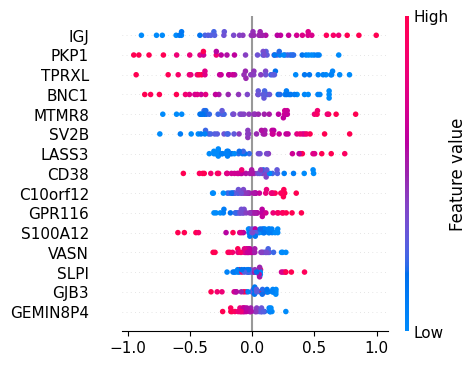

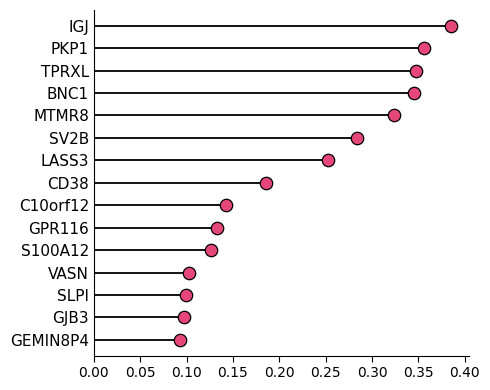


Running SHAP for model: ExtraTrees
Processing fold 1/5 for ExtraTrees...
Processing fold 2/5 for ExtraTrees...
Processing fold 3/5 for ExtraTrees...
Processing fold 4/5 for ExtraTrees...
Processing fold 5/5 for ExtraTrees...

Top 15 features sorted by mean |SHAP| for ExtraTrees:

['C10orf12', 'PKP1', 'GEMIN8P4', 'SV2B', 'PARL', 'IGJ', 'BNC1', 'TPRXL', 'SGK2', 'CCDC102B', 'CD38', 'TCEB2', 'LOC285629', 'TMEM220', 'CLIC5']

Numbered ranking:
 1. C10orf12    mean|SHAP| = 0.040794
 2. PKP1    mean|SHAP| = 0.029343
 3. GEMIN8P4    mean|SHAP| = 0.027114
 4. SV2B    mean|SHAP| = 0.025751
 5. PARL    mean|SHAP| = 0.025635
 6. IGJ    mean|SHAP| = 0.022766
 7. BNC1    mean|SHAP| = 0.021398
 8. TPRXL    mean|SHAP| = 0.020687
 9. SGK2    mean|SHAP| = 0.020300
10. CCDC102B    mean|SHAP| = 0.020163
11. CD38    mean|SHAP| = 0.019747
12. TCEB2    mean|SHAP| = 0.019431
13. LOC285629    mean|SHAP| = 0.018758
14. TMEM220    mean|SHAP| = 0.017734
15. CLIC5    mean|SHAP| = 0.017678


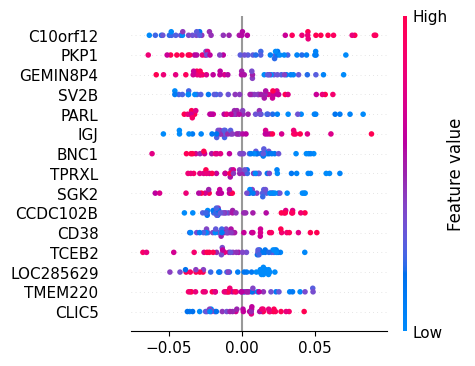

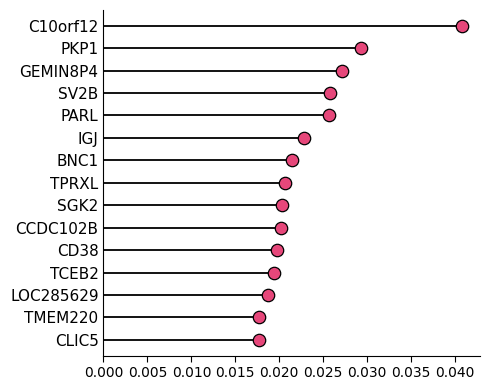


Running SHAP for model: NaiveBayes
Processing fold 1/5 for NaiveBayes...


  0%|          | 0/8 [00:00<?, ?it/s]

Processing fold 2/5 for NaiveBayes...


  0%|          | 0/8 [00:00<?, ?it/s]

Processing fold 3/5 for NaiveBayes...


...

Processing fold 4/5 for NaiveBayes...


  0%|          | 0/8 [00:00<?, ?it/s]

Processing fold 5/5 for NaiveBayes...


  0%|          | 0/8 [00:00<?, ?it/s]


Top 15 features sorted by mean |SHAP| for NaiveBayes:

['LOC285629', 'S100A12', 'C10orf12', 'CCDC102B', 'C19orf21', 'CLIC5', 'LASS3', 'PKP1', 'BNC1', 'SLPI', 'MTMR8', 'SGK2', 'IGJ', 'VASN', 'GEMIN8P4']

Numbered ranking:
 1. LOC285629    mean|SHAP| = 0.061055
 2. S100A12    mean|SHAP| = 0.034329
 3. C10orf12    mean|SHAP| = 0.031437
 4. CCDC102B    mean|SHAP| = 0.029660
 5. C19orf21    mean|SHAP| = 0.023264
 6. CLIC5    mean|SHAP| = 0.021031
 7. LASS3    mean|SHAP| = 0.020286
 8. PKP1    mean|SHAP| = 0.019867
 9. BNC1    mean|SHAP| = 0.018857
10. SLPI    mean|SHAP| = 0.018408
11. MTMR8    mean|SHAP| = 0.017907
12. SGK2    mean|SHAP| = 0.017881
13. IGJ    mean|SHAP| = 0.017810
14. VASN    mean|SHAP| = 0.017579
15. GEMIN8P4    mean|SHAP| = 0.017520


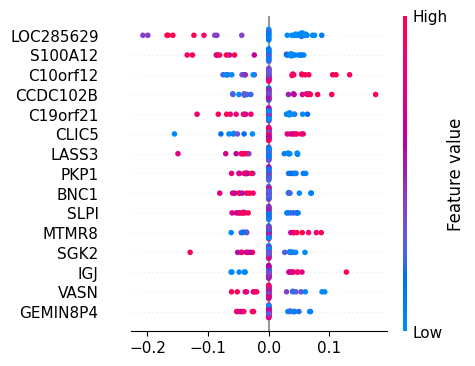

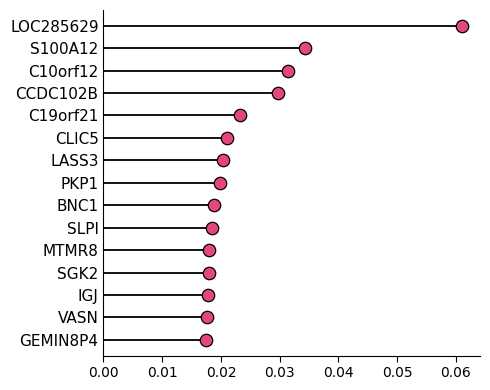


Number of unique SHAP genes from all three models: 23
Unique SHAP genes:
['IGJ', 'PKP1', 'TPRXL', 'BNC1', 'MTMR8', 'SV2B', 'LASS3', 'CD38', 'C10orf12', 'GPR116', 'S100A12', 'VASN', 'SLPI', 'GJB3', 'GEMIN8P4', 'PARL', 'SGK2', 'CCDC102B', 'TCEB2', 'LOC285629', 'TMEM220', 'CLIC5', 'C19orf21']

Saved dataset with unique SHAP genes and TumorType:
BEST_Subset_from_Step3.csv


In [ ]:
# ============================================================
# CONFIG
# ============================================================
INPUT_CSV = "BEST_Subset_from_Step2.csv"
TARGET_COL = "TumorType"
TOP_N = 15

N_SPLITS = 5
RANDOM_STATE_CV = 42
RANDOM_STATE_MODEL = 42


# ============================================================
# LOAD DATA
# ============================================================
data = pd.read_csv(INPUT_CSV)

X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL].values

feature_names = np.array(X.columns)


# ============================================================
# Update models. Consider top three performing models from step 2
# ============================================================

models = {
    "SVC": SVC(
        C=0.1,
        class_weight=None,
        gamma="scale",
        kernel="linear",
        probability=True
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "NaiveBayes": GaussianNB()
}


# ============================================================
# HELPER: normalize SHAP output
# ============================================================

def normalize_shap_values(shap_vals, n_features):
    """
    Convert SHAP output to shape:
    (n_samples, n_features)

    Handles:
    - list: [class0, class1]
    - 2D array: (n_samples, n_features)
    - 3D array: class dimension included
    """

    if isinstance(shap_vals, list):
        shap_arr = np.asarray(shap_vals[1]) if len(shap_vals) > 1 else np.asarray(shap_vals[0])
    else:
        shap_arr = np.asarray(shap_vals)

        # Case: (2, n_samples, n_features)
        if shap_arr.ndim == 3 and shap_arr.shape[0] == 2:
            shap_arr = shap_arr[1]

        # Case: (n_samples, n_features, 2)
        elif shap_arr.ndim == 3 and shap_arr.shape[-1] == 2:
            shap_arr = shap_arr[:, :, 1]

    if shap_arr.ndim != 2 or shap_arr.shape[1] != n_features:
        raise ValueError(
            f"Unexpected SHAP array shape {shap_arr.shape}; "
            f"expected (n_samples, n_features={n_features})"
        )

    return shap_arr


# ============================================================
# HELPER: get SHAP values for one model
# ============================================================

def get_shap_values_for_model(model_name, model, X_train, X_test):
    """
    Uses suitable SHAP explainer for each model:
    - SVC linear: LinearExplainer, fallback KernelExplainer
    - Extra Trees: TreeExplainer
    - Naive Bayes: KernelExplainer
    """

    if model_name == "SVC":

        try:
            explainer = shap.LinearExplainer(
                model,
                X_train,
                feature_perturbation="interventional"
            )

            shap_vals = explainer.shap_values(X_test)

        except Exception:
            background = shap.sample(
                X_train,
                min(100, X_train.shape[0]),
                random_state=RANDOM_STATE_MODEL
            )

            explainer = shap.KernelExplainer(
                model.predict_proba,
                background
            )

            shap_vals = explainer.shap_values(
                X_test,
                nsamples="auto"
            )


    elif model_name == "ExtraTrees":

        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_test)


    elif model_name == "NaiveBayes":

        background = shap.sample(
            X_train,
            min(100, X_train.shape[0]),
            random_state=RANDOM_STATE_MODEL
        )

        explainer = shap.KernelExplainer(
            model.predict_proba,
            background
        )

        shap_vals = explainer.shap_values(
            X_test,
            nsamples="auto"
        )

    else:
        raise ValueError(f"Unsupported model: {model_name}")

    return normalize_shap_values(
        shap_vals,
        n_features=X_train.shape[1]
    )


# ============================================================
# HELPER: make plots
# ============================================================

def make_shap_plots(model_name, shap_sorted, X_sorted, features_sorted, mean_abs_sorted):
    """
    Saves:
    - beeswarm plot as PNG
    - importance dot plot as PNG
    """

    # --------------------
    # Beeswarm plot
    # --------------------
    shap.summary_plot(
        shap_sorted,
        X_sorted,
        feature_names=list(features_sorted),
        max_display=len(features_sorted),
        show=False,
        plot_size=(5, 4)
    )

    ax = plt.gca()
    ax.tick_params(axis="both", colors="black")

    for spine in ax.spines.values():
        spine.set_edgecolor("black")

    plt.tight_layout()
    plt.yticks(fontsize=11)
    plt.xlabel("")

    plt.savefig(
        f"{model_name}_beeswarm_overall.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


    # --------------------
    # Variable importance dot plot
    # --------------------
    plt.figure(figsize=(5, 4))

    y_pos = np.arange(len(features_sorted))

    for yi, xi in zip(y_pos, mean_abs_sorted):
        plt.hlines(
            yi,
            xmin=0,
            xmax=xi,
            color="black",
            linewidth=1.3,
            zorder=1.5
        )

    plt.scatter(
        mean_abs_sorted,
        y_pos,
        s=80,
        marker="o",
        facecolors="#E6477A",
        edgecolors="black",
        linewidths=0.9,
        zorder=3
    )

    ax = plt.gca()

    ax.tick_params(axis="y", which="both", length=0)
    ax.tick_params(axis="x", which="both", length=4)

    plt.yticks(y_pos, features_sorted, fontsize=11)
    plt.gca().invert_yaxis()
    plt.xlim(left=0)
    plt.grid(False)

    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    plt.tight_layout()

    plt.savefig(
        f"{model_name}_importance_overall.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ============================================================
# MAIN LOOP: SVC, Extra Trees, Naive Bayes
# ============================================================

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE_CV
)

all_model_rankings = []

for model_name, base_model in models.items():

    print("\n" + "=" * 70)
    print(f"Running SHAP for model: {model_name}")
    print("=" * 70)

    shap_values_list = []
    X_rows_list = []
    y_rows_list = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

        print(f"Processing fold {fold}/{N_SPLITS} for {model_name}...")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        model = clone(base_model)
        model.fit(X_train, y_train)

        shap_arr = get_shap_values_for_model(
            model_name=model_name,
            model=model,
            X_train=X_train,
            X_test=X_test
        )

        shap_values_list.append(shap_arr)
        X_rows_list.append(X_test)
        y_rows_list.append(y_test)


    # ========================================================
    # Concatenate out-of-fold SHAP values
    # ========================================================

    all_shap_values = np.vstack(shap_values_list)
    all_X = pd.concat(X_rows_list, axis=0)
    all_y = np.concatenate(y_rows_list)


    # ========================================================
    # Rank features by mean absolute SHAP
    # ========================================================

    mean_abs_shap = np.abs(all_shap_values).mean(axis=0)

    top_indices = np.argsort(mean_abs_shap)[::-1][:TOP_N]

    features_top = feature_names[top_indices]
    mean_abs_top = mean_abs_shap[top_indices]

    order = np.argsort(mean_abs_top)[::-1]

    features_sorted = features_top[order]
    mean_abs_sorted = mean_abs_top[order]

    shap_sorted = all_shap_values[:, top_indices][:, order]
    X_sorted = all_X.iloc[:, top_indices].iloc[:, order]


    # ========================================================
    # Print ranking
    # ========================================================

    print(f"\nTop {TOP_N} features sorted by mean |SHAP| for {model_name}:\n")
    print(list(features_sorted))

    print("\nNumbered ranking:")

    for i, (feat, val) in enumerate(
        zip(features_sorted, mean_abs_sorted),
        start=1
    ):
        print(f"{i:2d}. {feat}    mean|SHAP| = {val:.6f}")

        all_model_rankings.append({
            "Model": model_name,
            "Rank": i,
            "Feature": feat,
            "MeanAbsSHAP": val
        })


    # ========================================================
    # Save plots
    # ========================================================

    make_shap_plots(
        model_name=model_name,
        shap_sorted=shap_sorted,
        X_sorted=X_sorted,
        features_sorted=features_sorted,
        mean_abs_sorted=mean_abs_sorted
    )


# ============================================================
# SAVE COMBINED SHAP RANKING TABLE
# ============================================================
ranking_df = pd.DataFrame(all_model_rankings)

# Get unique genes selected by SHAP across top three models
unique_shap_genes = ranking_df["Feature"].dropna().unique().tolist()

# Keep only genes that actually exist in the original dataset
unique_shap_genes = [gene for gene in unique_shap_genes if gene in data.columns]

print("\nNumber of unique SHAP genes from all three models:", len(unique_shap_genes))
print("Unique SHAP genes:")
print(unique_shap_genes)

# Create new dataframe with only unique SHAP genes and TumorType
unique_shap_dataset = data[unique_shap_genes].copy()
unique_shap_dataset[TARGET_COL] = data[TARGET_COL].values

# Save new dataset
unique_shap_dataset.to_csv(
    "BEST_Subset_from_Step3.csv",
    index=False
)

print("\nSaved dataset with unique SHAP genes and TumorType:")
print("BEST_Subset_from_Step3.csv")

**Step-4: Prognostic Verification and Clinical
Translation**

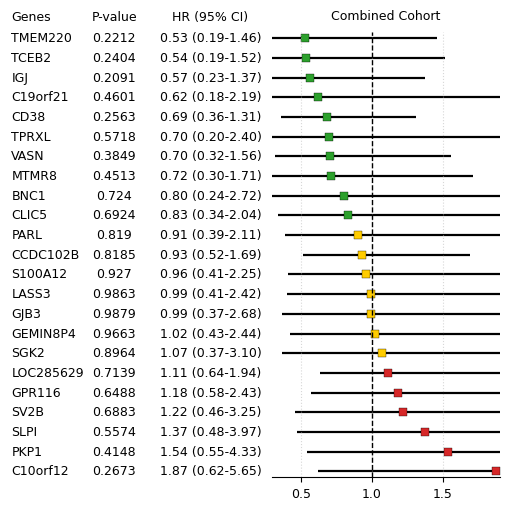

In [ ]:
# ---------------- USER SETTINGS ----------------
# Update your genes list
csv_file = "Sample_BEST_Subset_from_Step3_with_Survival_Data.csv.csv"
genes = [
    'IGJ', 'PKP1', 'TPRXL', 'BNC1', 'MTMR8', 'SV2B', 'LASS3', 'CD38', 'C10orf12', 'GPR116', 'S100A12', 'VASN', 'SLPI', 'GJB3', 'GEMIN8P4', 'PARL', 'SGK2', 'CCDC102B', 'TCEB2', 'LOC285629', 'TMEM220', 'CLIC5', 'C19orf21'
]

# Layout: genes | p-value | HR text | forest
width_ratios = [0.085, 0.085, 0.15, 0.28]
font_size = 9
spacing_scale = 0.65

# Forest look
xleft, xright = (0.3, 1.9)
marker_size = 6
line_width = 1.6
hlines_color = "black"
vline_color = "black"

# ---------------- HELPERS ----------------
def fmt_p(p):
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return "NA"
    p = float(p)
    if p == 0:
        return "0"
    if p < 1e-4:
        return f"{p:.1e}"
    s = f"{p:.4f}"
    return s.rstrip("0").rstrip(".")

def fmt_hr(hr, lo, hi):
    if any(pd.isna([hr, lo, hi])):
        return "NA"
    return f"{hr:.2f} ({lo:.2f}-{hi:.2f})"

def hr_color(hr, low=0.90, high=1.10):
    if hr is None or (isinstance(hr, float) and np.isnan(hr)):
        return "#B0B0B0"
    if hr < low:
        return "#2ca02c"
    if hr <= high:
        return "#ffcc00"
    return "#d62728"

# ---------------- LOAD DATA ----------------
cols = genes + ["TumorType", "OS", "OS.time"]
df = pd.read_csv(csv_file, usecols=lambda c: c in cols).dropna(subset=["OS", "OS.time", "TumorType"])
df["OS"] = df["OS"].astype(int)
df["OS.time"] = df["OS.time"].astype(float)

# ---------------- COX PER GENE (COMBINED ONLY) ----------------
out = []
for g in genes:
    d = df.dropna(subset=[g]).copy()
    n = len(d)
    events = int(d["OS"].sum())
    x = d[g].astype(float)
    iqr = float(x.quantile(0.75) - x.quantile(0.25))

    p = hr = lo = hi = np.nan
    if n > 0 and events > 0 and x.nunique() > 1 and np.isfinite(iqr) and iqr > 0:
        try:
            cox = d[["OS.time", "OS", "TumorType"]].copy()
            cox["x"] = x.values
            cph = CoxPHFitter()
            cph.fit(cox, duration_col="OS.time", event_col="OS", strata=["TumorType"])

            beta = float(cph.summary.loc["x", "coef"])
            se = float(cph.summary.loc["x", "se(coef)"])
            p = float(cph.summary.loc["x", "p"])

            # HR
            hr = math.exp(beta * iqr)
            lo = math.exp((beta - 1.96 * se) * iqr)
            hi = math.exp((beta + 1.96 * se) * iqr)
        except Exception:
            pass

    out.append({"gene": g, "p": p, "hr": hr, "lo": lo, "hi": hi})

res = pd.DataFrame(out).sort_values("hr", ascending=True, na_position="last").reset_index(drop=True)

# ---------------- PLOT ----------------
plt.rcParams.update({"font.size": font_size})
fig = plt.figure(figsize=(5, 5))
gs = gridspec.GridSpec(1, 4, width_ratios=width_ratios, wspace=0.005)

ax_gene = fig.add_subplot(gs[0])
ax_p = fig.add_subplot(gs[1])
ax_txt = fig.add_subplot(gs[2])
ax_forest = fig.add_subplot(gs[3])

y = (np.arange(len(res))[::-1]).astype(float) * spacing_scale

# Forest panel
ax_forest.set_xlim(xleft, xright)
ax_forest.set_yticks([])
ax_forest.grid(axis="x", linestyle=":", alpha=0.5)
ax_forest.axvline(1.0, color=vline_color, linestyle="--", linewidth=1)
for sp in ("left", "right", "top"):
    ax_forest.spines[sp].set_visible(False)

for i, r in res.iterrows():
    yy = y[i]
    hr, lo, hi = r["hr"], r["lo"], r["hi"]
    if pd.notna(lo) and pd.notna(hi):
        ax_forest.hlines(yy, lo, hi, color=hlines_color, linewidth=line_width, zorder=1)
    if pd.notna(hr):
        ax_forest.plot(hr, yy, marker="s", linestyle="None",
                       markerfacecolor=hr_color(hr), markeredgecolor="black",
                       markeredgewidth=0.25, markersize=marker_size, zorder=1.5)
    else:
        ax_forest.plot((xleft + xright) / 2, yy, "x", color="#B0B0B0", alpha=0.45, zorder=1.5)

# Shared y-lims (so text aligns with forest)
ymin, ymax = float(y.min()), float(y.max())
pad = 0.3 * spacing_scale
for ax in (ax_gene, ax_p, ax_txt, ax_forest):
    ax.set_ylim(ymin - pad, ymax + pad)

ax_forest.set_title("Combined Cohort", y=1.01, fontsize = 9)

# Text columns
for ax in (ax_gene, ax_p, ax_txt):
    ax.set_xlim(0, 1)
    ax.axis("off")

ax_gene.text(0.02, 1.02, "Genes", transform=ax_gene.transAxes, ha="left", va="bottom")
ax_p.text(0.5, 1.02, "P-value", transform=ax_p.transAxes, ha="center", va="bottom")
ax_txt.text(0.5, 1.02, "HR (95% CI)", transform=ax_txt.transAxes, ha="center", va="bottom")

for i, r in res.iterrows():
    yy = y[i]
    ax_gene.text(0.02, yy, r["gene"], ha="left", va="center", transform=ax_gene.transData)
    ax_p.text(0.5, yy, fmt_p(r["p"]), ha="center", va="center", transform=ax_p.transData)
    ax_txt.text(0.5, yy, fmt_hr(r["hr"], r["lo"], r["hi"]),
                ha="center", va="center", transform=ax_txt.transData)

plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.03)
plt.savefig("forest_plot.png", bbox_inches='tight')
plt.show()

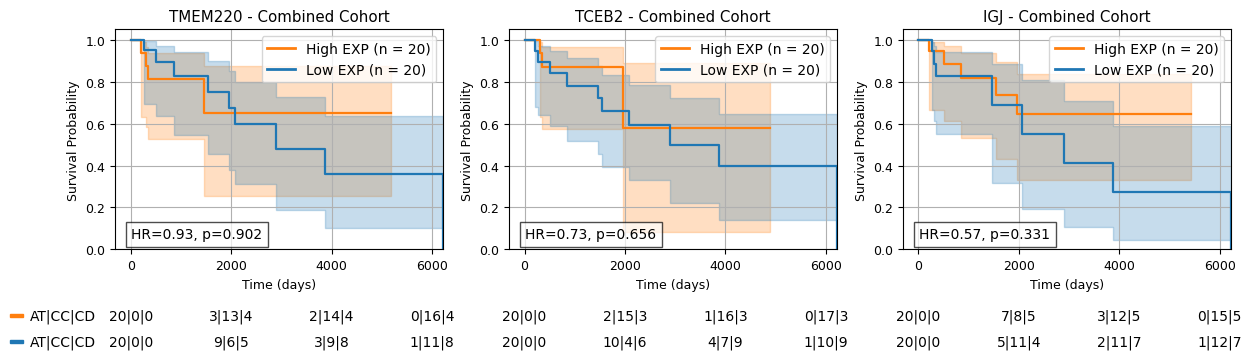

In [ ]:
genes = ['TMEM220', 'TCEB2', 'IGJ'] #Randomly picked, update the protective genes list
columns = genes + ['TumorType', 'OS', 'OS.time']

df = pd.read_csv("Sample_BEST_Subset_from_Step3_with_Survival_Data.csv.csv", usecols=lambda c: c in columns)
df['OS'] = df['OS'].astype(int)
df['OS.time'] = df['OS.time'].astype(float)

# ONLY Combined cohort
tumor_types = ['Combined']

# Keep same per-panel size as the original 3x3 figure (14x14)
# Original panel size ~ (14/3, 14/3). Now 1 row x 3 panels => figsize=(14, 14/3)
fig, axes = plt.subplots(
    nrows=1, ncols=len(genes), figsize=(12, 12/3),
    gridspec_kw={'hspace': 0.6, 'wspace': 0.2}
)

# If axes is not an array (edge cases), normalize it
axes = np.array(axes).reshape(1, len(genes))

def get_cumulative_stats(times, events, xticks):
    n = len(times)
    cum_death, cum_censored, at_risk = [], [], []
    for tick in xticks:
        deaths = np.sum((events == 1) & (times < tick))
        censored = np.sum((events == 0) & (times < tick))
        still_at_risk = n - deaths - censored
        cum_death.append(deaths)
        cum_censored.append(censored)
        at_risk.append(still_at_risk)
    return at_risk, cum_censored, cum_death

at_risk_table = {}

for col, gene in enumerate(genes):
    ax = axes[0, col]

    subset = df.copy()  # Combined = all samples
    if subset.empty or gene not in subset:
        ax.axis('off')
        continue

    median_expr = subset[gene].median()
    subset['exp_group'] = np.where(subset[gene] > median_expr, 'High', 'Low')

    T = subset['OS.time'].to_numpy()
    E = subset['OS'].to_numpy()
    groups = subset['exp_group']

    colors = {'High': 'tab:orange', 'Low': 'tab:blue'}

    legend_handles, legend_labels = [], []
    for label in ['High', 'Low']:
        mask = (groups == label)
        n_samples = mask.sum()
        if n_samples == 0:
            continue
        legend_label = f"{label} EXP (n = {n_samples})"
        kmf = KaplanMeierFitter()
        kmf.fit(T[mask], event_observed=E[mask], label=legend_label)
        handle = kmf.plot_survival_function(ax=ax, color=colors[label], linewidth=1.6).get_lines()[-1]
        legend_handles.append(handle)
        legend_labels.append(legend_label)

    # Axis limits with padding
    min_time = 0
    max_time = subset['OS.time'].max()
    left_pad = 0.05
    upper_pad = 0.05
    x_range = max_time - min_time
    ax.set_xlim([min_time - left_pad * x_range, max_time])
    ax.set_ylim([0, 1 + upper_pad])

    # Combined ticks (same as your original "else" branch)
    xticks = [0, 2000, 4000, 6000]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])

    # AT / CC / CD stats for each group
    group_stats, cum_censored_stats, cum_death_stats = {}, {}, {}
    for label in ['High', 'Low']:
        mask = (groups == label)
        t_group = T[mask]
        e_group = E[mask]
        arisk, ccensored, cdeath = get_cumulative_stats(t_group, e_group, xticks)
        group_stats[label] = arisk
        cum_censored_stats[label] = ccensored
        cum_death_stats[label] = cdeath

    at_risk_table[(0, col)] = {
        'xticks': xticks,
        'high_atrisk': group_stats['High'],
        'low_atrisk': group_stats['Low'],
        'high_censored': cum_censored_stats['High'],
        'low_censored': cum_censored_stats['Low'],
        'high_death': cum_death_stats['High'],
        'low_death': cum_death_stats['Low'],
        'ax': ax
    }

    # Log-rank p-value
    mask_high = (groups == 'High')
    mask_low = (groups == 'Low')
    if mask_high.sum() > 0 and mask_low.sum() > 0:
        result = logrank_test(
            T[mask_high], T[mask_low],
            event_observed_A=E[mask_high],
            event_observed_B=E[mask_low]
        )
        p_value = result.p_value
    else:
        p_value = float('nan')

    # Cox HR (binary high vs low)
    cox_df = subset[[gene, 'OS.time', 'OS']].copy()
    cox_df['exp_group'] = (subset[gene] > median_expr).astype(int)
    cox_df['event'] = cox_df['OS']
    try:
        cph = CoxPHFitter()
        cph.fit(cox_df[['OS.time', 'event', 'exp_group']],
                duration_col='OS.time', event_col='event')
        hr = float(cph.hazard_ratios_['exp_group'])
    except Exception:
        hr = float('nan')

    annotation = f'HR={hr:.2f}, p={p_value:.3g}'
    ax.text(0.05, 0.05, annotation, transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

    ax.set_title(f'{gene} - Combined Cohort')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Survival Probability')
    ax.grid(True)

    legend = ax.legend(handles=legend_handles, labels=legend_labels,
                       fontsize=10, loc="upper right", frameon=True)
    for legline in legend.get_lines():
        legline.set_linewidth(2)

# Adjust margins: keep enough bottom space for the AT|CC|CD table
plt.subplots_adjust(bottom=0.35, top=0.90, left=0.06, right=0.99)

# Positioning for at-risk table
y_high = -0.30
y_low = -0.42
bar_y_high = y_high
bar_y_low = y_low
label_x = -0.32
bar_width = 0.04
bar_height = 0.015

# Draw AT|CC|CD table under each plot
for col in range(len(genes)):
    d = at_risk_table.get((0, col), None)
    if d is None:
        continue
    ax = d['ax']
    xticks = d['xticks']

    high_atrisk = d['high_atrisk']
    low_atrisk = d['low_atrisk']
    high_censored = d['high_censored']
    low_censored = d['low_censored']
    high_death = d['high_death']
    low_death = d['low_death']

    xlim = ax.get_xlim()
    if xlim[1] - xlim[0] == 0:
        x_frac = [0] * len(xticks)
    else:
        x_frac = [(x - xlim[0]) / (xlim[1] - xlim[0]) for x in xticks]

    # Only for the leftmost plot, draw the colored bars and header text
    if col == 0:
        ax.add_patch(Rectangle((label_x, bar_y_high - bar_height / 2), bar_width, bar_height,
                               color="tab:orange", transform=ax.transAxes, clip_on=False))
        ax.text(label_x + bar_width + 0.02, bar_y_high, "AT|CC|CD", ha='left', va='center',
                color='black', fontsize=10, transform=ax.transAxes)

        ax.add_patch(Rectangle((label_x, bar_y_low - bar_height / 2), bar_width, bar_height,
                               color="tab:blue", transform=ax.transAxes, clip_on=False))
        ax.text(label_x + bar_width + 0.02, bar_y_low, "AT|CC|CD", ha='left', va='center',
                color='black', fontsize=10, transform=ax.transAxes)

    for i, frac in enumerate(x_frac):
        ax.text(frac, y_high, f"{high_atrisk[i]}|{high_censored[i]}|{high_death[i]}",
                ha='center', va='center', color='black', fontsize=10, transform=ax.transAxes)
        ax.text(frac, y_low, f"{low_atrisk[i]}|{low_censored[i]}|{low_death[i]}",
                ha='center', va='center', color='black', fontsize=10, transform=ax.transAxes)

plt.savefig("Protective Genes.png", bbox_inches="tight")
plt.show()

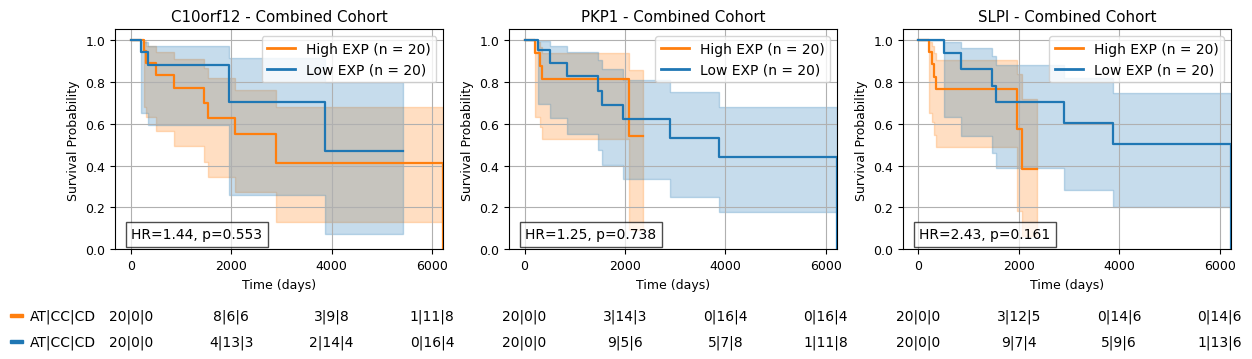

In [ ]:
genes = ['C10orf12', 'PKP1', 'SLPI'] #Randomly picked, update the risk genes list
columns = genes + ['TumorType', 'OS', 'OS.time']

df = pd.read_csv("Sample_BEST_Subset_from_Step3_with_Survival_Data.csv.csv", usecols=lambda c: c in columns)
df['OS'] = df['OS'].astype(int)
df['OS.time'] = df['OS.time'].astype(float)

# ONLY Combined cohort
tumor_types = ['Combined']

# Keep same per-panel size as the original 3x3 figure (14x14)
# Original panel size ~ (14/3, 14/3). Now 1 row x 3 panels => figsize=(14, 14/3)
fig, axes = plt.subplots(
    nrows=1, ncols=len(genes), figsize=(12, 12/3),
    gridspec_kw={'hspace': 0.6, 'wspace': 0.2}
)

# If axes is not an array (edge cases), normalize it
axes = np.array(axes).reshape(1, len(genes))

def get_cumulative_stats(times, events, xticks):
    n = len(times)
    cum_death, cum_censored, at_risk = [], [], []
    for tick in xticks:
        deaths = np.sum((events == 1) & (times < tick))
        censored = np.sum((events == 0) & (times < tick))
        still_at_risk = n - deaths - censored
        cum_death.append(deaths)
        cum_censored.append(censored)
        at_risk.append(still_at_risk)
    return at_risk, cum_censored, cum_death

at_risk_table = {}

for col, gene in enumerate(genes):
    ax = axes[0, col]

    subset = df.copy()  # Combined = all samples
    if subset.empty or gene not in subset:
        ax.axis('off')
        continue

    median_expr = subset[gene].median()
    subset['exp_group'] = np.where(subset[gene] > median_expr, 'High', 'Low')

    T = subset['OS.time'].to_numpy()
    E = subset['OS'].to_numpy()
    groups = subset['exp_group']

    colors = {'High': 'tab:orange', 'Low': 'tab:blue'}

    legend_handles, legend_labels = [], []
    for label in ['High', 'Low']:
        mask = (groups == label)
        n_samples = mask.sum()
        if n_samples == 0:
            continue
        legend_label = f"{label} EXP (n = {n_samples})"
        kmf = KaplanMeierFitter()
        kmf.fit(T[mask], event_observed=E[mask], label=legend_label)
        handle = kmf.plot_survival_function(ax=ax, color=colors[label], linewidth=1.6).get_lines()[-1]
        legend_handles.append(handle)
        legend_labels.append(legend_label)

    # Axis limits with padding
    min_time = 0
    max_time = subset['OS.time'].max()
    left_pad = 0.05
    upper_pad = 0.05
    x_range = max_time - min_time
    ax.set_xlim([min_time - left_pad * x_range, max_time])
    ax.set_ylim([0, 1 + upper_pad])

    # Combined ticks (same as your original "else" branch)
    xticks = [0, 2000, 4000, 6000]
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(x) for x in xticks])

    # AT / CC / CD stats for each group
    group_stats, cum_censored_stats, cum_death_stats = {}, {}, {}
    for label in ['High', 'Low']:
        mask = (groups == label)
        t_group = T[mask]
        e_group = E[mask]
        arisk, ccensored, cdeath = get_cumulative_stats(t_group, e_group, xticks)
        group_stats[label] = arisk
        cum_censored_stats[label] = ccensored
        cum_death_stats[label] = cdeath

    at_risk_table[(0, col)] = {
        'xticks': xticks,
        'high_atrisk': group_stats['High'],
        'low_atrisk': group_stats['Low'],
        'high_censored': cum_censored_stats['High'],
        'low_censored': cum_censored_stats['Low'],
        'high_death': cum_death_stats['High'],
        'low_death': cum_death_stats['Low'],
        'ax': ax
    }

    # Log-rank p-value
    mask_high = (groups == 'High')
    mask_low = (groups == 'Low')
    if mask_high.sum() > 0 and mask_low.sum() > 0:
        result = logrank_test(
            T[mask_high], T[mask_low],
            event_observed_A=E[mask_high],
            event_observed_B=E[mask_low]
        )
        p_value = result.p_value
    else:
        p_value = float('nan')

    # Cox HR (binary high vs low)
    cox_df = subset[[gene, 'OS.time', 'OS']].copy()
    cox_df['exp_group'] = (subset[gene] > median_expr).astype(int)
    cox_df['event'] = cox_df['OS']
    try:
        cph = CoxPHFitter()
        cph.fit(cox_df[['OS.time', 'event', 'exp_group']],
                duration_col='OS.time', event_col='event')
        hr = float(cph.hazard_ratios_['exp_group'])
    except Exception:
        hr = float('nan')

    annotation = f'HR={hr:.2f}, p={p_value:.3g}'
    ax.text(0.05, 0.05, annotation, transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

    ax.set_title(f'{gene} - Combined Cohort')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Survival Probability')
    ax.grid(True)

    legend = ax.legend(handles=legend_handles, labels=legend_labels,
                       fontsize=10, loc="upper right", frameon=True)
    for legline in legend.get_lines():
        legline.set_linewidth(2)

# Adjust margins: keep enough bottom space for the AT|CC|CD table
plt.subplots_adjust(bottom=0.35, top=0.90, left=0.06, right=0.99)

# Positioning for at-risk table
y_high = -0.30
y_low = -0.42
bar_y_high = y_high
bar_y_low = y_low
label_x = -0.32
bar_width = 0.04
bar_height = 0.015

# Draw AT|CC|CD table under each plot
for col in range(len(genes)):
    d = at_risk_table.get((0, col), None)
    if d is None:
        continue
    ax = d['ax']
    xticks = d['xticks']

    high_atrisk = d['high_atrisk']
    low_atrisk = d['low_atrisk']
    high_censored = d['high_censored']
    low_censored = d['low_censored']
    high_death = d['high_death']
    low_death = d['low_death']

    xlim = ax.get_xlim()
    if xlim[1] - xlim[0] == 0:
        x_frac = [0] * len(xticks)
    else:
        x_frac = [(x - xlim[0]) / (xlim[1] - xlim[0]) for x in xticks]

    # Only for the leftmost plot, draw the colored bars and header text
    if col == 0:
        ax.add_patch(Rectangle((label_x, bar_y_high - bar_height / 2), bar_width, bar_height,
                               color="tab:orange", transform=ax.transAxes, clip_on=False))
        ax.text(label_x + bar_width + 0.02, bar_y_high, "AT|CC|CD", ha='left', va='center',
                color='black', fontsize=10, transform=ax.transAxes)

        ax.add_patch(Rectangle((label_x, bar_y_low - bar_height / 2), bar_width, bar_height,
                               color="tab:blue", transform=ax.transAxes, clip_on=False))
        ax.text(label_x + bar_width + 0.02, bar_y_low, "AT|CC|CD", ha='left', va='center',
                color='black', fontsize=10, transform=ax.transAxes)

    for i, frac in enumerate(x_frac):
        ax.text(frac, y_high, f"{high_atrisk[i]}|{high_censored[i]}|{high_death[i]}",
                ha='center', va='center', color='black', fontsize=10, transform=ax.transAxes)
        ax.text(frac, y_low, f"{low_atrisk[i]}|{low_censored[i]}|{low_death[i]}",
                ha='center', va='center', color='black', fontsize=10, transform=ax.transAxes)

plt.savefig("Risk Genes.png", bbox_inches="tight")
plt.show()